# Regression Track — Predicting Weight
### 23CSE301 Machine Learning Capstone — "Predicting Obesity Levels"
**Dataset:** Estimation of Obesity Levels Based on Eating Habits and Physical Condition (UCI)
**Target:** `Weight` (kg) — continuous variable
**Scope:** Review 1 — all 10 required regression algorithms

**Important — data leakage note:** `NObeyesdad` (the obesity class) is *derived directly* from BMI = Weight / Height², so it is dropped from the feature set here. Including it would leak the target.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
sns.set_palette("colorblind")
plt.rcParams["figure.dpi"] = 100

## Section A — Dataset Loading & Audit

In [2]:
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.describe(include="all").T

Shape: (2111, 17)

Data types:
 Gender                                str
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight        str
FAVC                                  str
FCVC                              float64
NCP                               float64
CAEC                                  str
SMOKE                                 str
CH2O                              float64
SCC                                   str
FAF                               float64
TUE                               float64
CALC                                  str
MTRANS                                str
NObeyesdad                            str
dtype: object

Missing values per column:
 Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                           

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,2111,2,Male,1068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,2111.0,NaN,NaN,NaN,24.3126,6.345968,14.0,19.947192,22.77789,26.0,61.0
Height,2111.0,NaN,NaN,NaN,1.701677,0.093305,1.45,1.63,1.700499,1.768464,1.98
Weight,2111.0,NaN,NaN,NaN,86.586058,26.191172,39.0,65.473343,83.0,107.430682,173.0
family_history_with_overweight,2111,2,yes,1726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FAVC,2111,2,yes,1866,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FCVC,2111.0,NaN,NaN,NaN,2.419043,0.533927,1.0,2.0,2.385502,3.0,3.0
NCP,2111.0,NaN,NaN,NaN,2.685628,0.778039,1.0,2.658738,3.0,3.0,4.0
CAEC,2111,4,Sometimes,1765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SMOKE,2111,2,no,2067,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Target (Weight) distribution:")
df["Weight"].describe()

Target (Weight) distribution:


count    2111.000000
mean       86.586058
std        26.191172
min        39.000000
25%        65.473343
50%        83.000000
75%       107.430682
max       173.000000
Name: Weight, dtype: float64

**Observation:** The dataset has 2,111 rows and 17 columns with no missing values reported by `isnull()`. However, we should still check for duplicate rows and outliers before modelling (Section B).

## Section A2/A3 — EDA Visualisations & Insights

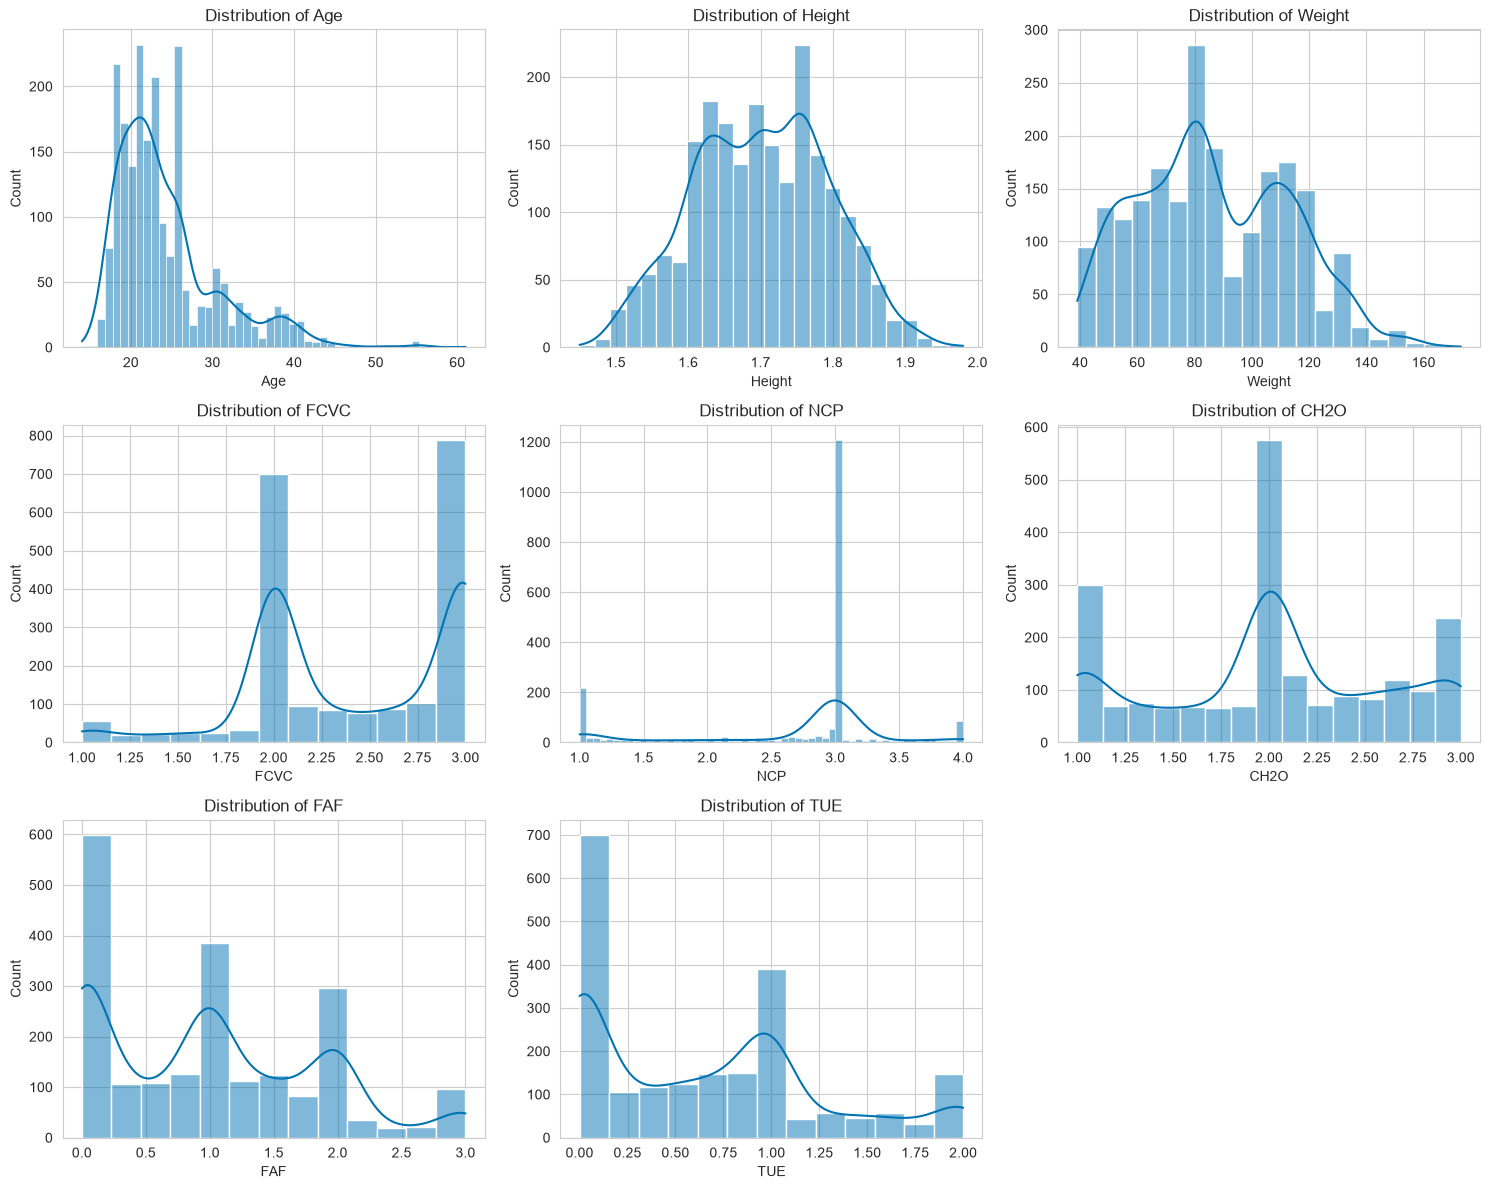

In [4]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=sns.color_palette("colorblind")[0])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("reg_distributions.png", bbox_inches="tight")
plt.show()

**Insight:** `Weight` and `Height` are fairly spread out with no extreme skew. `FCVC`, `NCP`, `CH2O`, `FAF`, and `TUE` show clustering around a few common survey-response values (typical of self-reported lifestyle data), which is worth remembering when interpreting model coefficients.

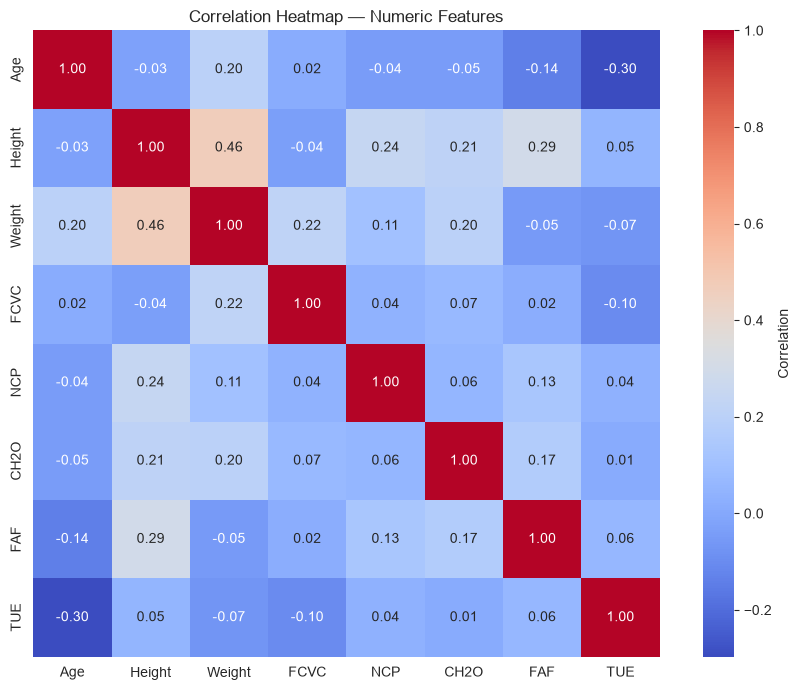

In [5]:
plt.figure(figsize=(9, 7))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"label": "Correlation"})
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.savefig("reg_corr_heatmap.png", bbox_inches="tight")
plt.show()

**Insight:** `Height` and `Weight` show the strongest correlation among numeric features, as expected physiologically. Lifestyle variables (`FAF`, `TUE`, `CH2O`) show weak-to-moderate correlation with `Weight`, suggesting a purely linear model may underfit and tree/ensemble methods could capture more signal.

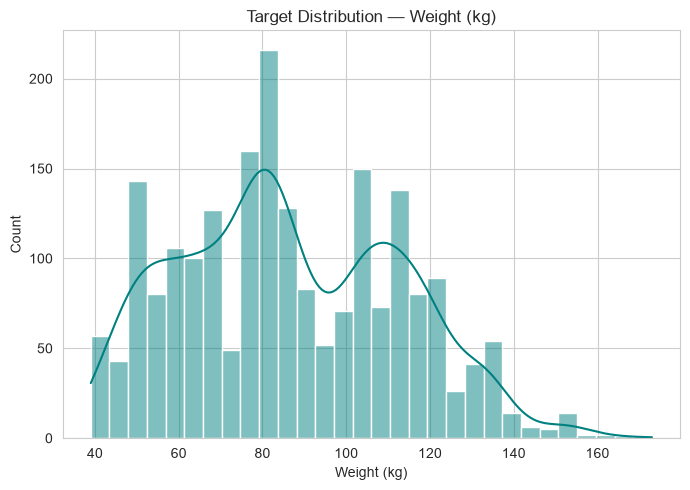

In [6]:
plt.figure(figsize=(7, 5))
sns.histplot(df["Weight"], kde=True, bins=30, color="teal")
plt.title("Target Distribution — Weight (kg)")
plt.xlabel("Weight (kg)")
plt.tight_layout()
plt.savefig("reg_target_dist.png", bbox_inches="tight")
plt.show()

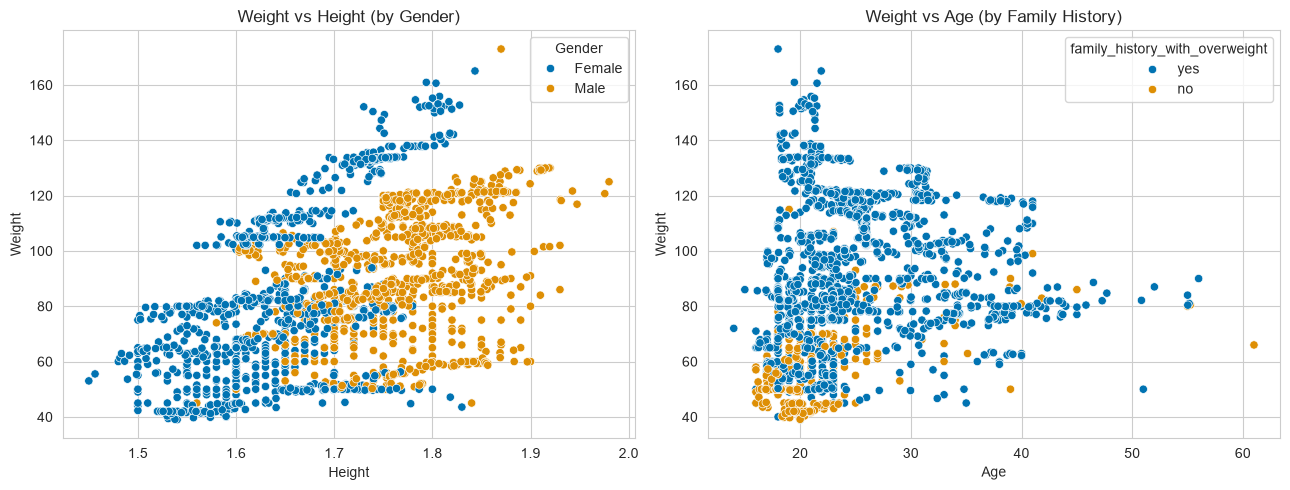

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x="Height", y="Weight", hue="Gender", ax=axes[0])
axes[0].set_title("Weight vs Height (by Gender)")

sns.scatterplot(data=df, x="Age", y="Weight", hue="family_history_with_overweight", ax=axes[1])
axes[1].set_title("Weight vs Age (by Family History)")
plt.tight_layout()
plt.savefig("reg_scatter_feature_target.png", bbox_inches="tight")
plt.show()

**Insight:** Weight increases with Height as expected. Individuals with a family history of overweight visibly skew toward higher weights across most ages, hinting that `family_history_with_overweight` will be a useful categorical predictor.

## Section B — Preprocessing & Feature Engineering

**B1 — Cleaning:** No missing values were found. We check and (if any) drop exact duplicate rows. Outliers in numeric columns are inspected via boxplots rather than blindly removed, since this is self-reported survey data where extreme-but-valid values are expected.

Removed 24 duplicate rows. New shape: (2087, 17)


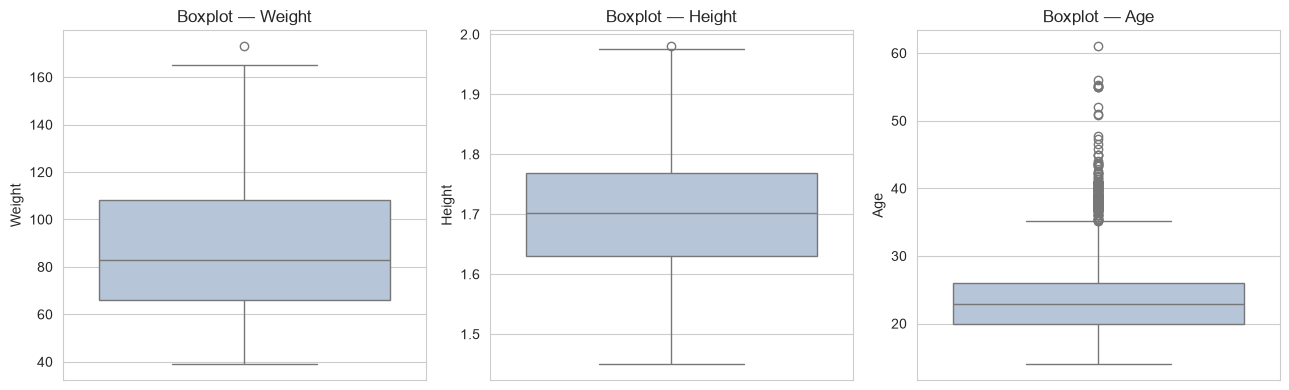

In [8]:
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - df.shape[0]} duplicate rows. New shape: {df.shape}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ["Weight", "Height", "Age"]):
    sns.boxplot(y=df[col], ax=ax, color="lightsteelblue")
    ax.set_title(f"Boxplot — {col}")
plt.tight_layout()
plt.savefig("reg_boxplots.png", bbox_inches="tight")
plt.show()

**B3 — Feature Engineering:** We engineer `Veg_Meal_Ratio = FCVC / NCP`, the ratio of vegetable-consumption frequency to number of main meals. This captures dietary quality *relative* to eating frequency (someone eating vegetables often but in only 1 meal/day differs from someone doing so across 4 meals/day) — a signal not directly present in either raw column alone. Note this uses only feature columns, not the target, so it introduces no leakage.

In [9]:
df["Veg_Meal_Ratio"] = df["FCVC"] / df["NCP"].replace(0, np.nan)
df["Veg_Meal_Ratio"] = df["Veg_Meal_Ratio"].fillna(df["Veg_Meal_Ratio"].median())
df[["FCVC", "NCP", "Veg_Meal_Ratio"]].head()

,FCVC,NCP,Veg_Meal_Ratio
0,2.0,3.0,0.666667
1,3.0,3.0,1.000000
2,2.0,3.0,0.666667
3,3.0,3.0,1.000000
4,2.0,1.0,2.000000


**B2 — Encoding, Scaling & Splitting:** Categorical columns are one-hot encoded. `NObeyesdad` is dropped (data leakage, see top of notebook). We split 80:20 **before** fitting the scaler, and fit the `StandardScaler` on the training data only, then transform both train and test — avoiding leakage from test-set statistics.

In [10]:
target = "Weight"
X = df.drop(columns=[target, "NObeyesdad"])
y = df[target]

cat_cols = X.select_dtypes(exclude="number").columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("Categorical columns encoded:", cat_cols)
print("Encoded feature matrix shape:", X_encoded.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on TRAIN only
X_test_scaled = scaler.transform(X_test)         # transform TEST with train's scaler

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Categorical columns encoded: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
Encoded feature matrix shape: (2087, 23)
Train shape: (1669, 23)  Test shape: (418, 23)


## Section C — Regression Track: All 10 Required Algorithms

In [11]:
results = []
fitted_models = {}

def evaluate(name, model, Xtr, Xte, store=True):
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    if store:
        results.append({"Model": name, "R2": r2, "RMSE": rmse, "MAE": mae})
        fitted_models[name] = (model, preds)
    return model, preds

In [12]:
# 1. Linear Regression (baseline)
lin_model, _ = evaluate("Linear Regression", LinearRegression(), X_train_scaled, X_test_scaled)
coefs = pd.Series(lin_model.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
print("Top 10 |coefficient| features (Linear Regression):")
print(coefs.head(10))

Top 10 |coefficient| features (Linear Regression):
Height                                11.078079
Veg_Meal_Ratio                        -8.881962
FCVC                                   8.226490
NCP                                   -7.270432
family_history_with_overweight_yes     7.119000
MTRANS_Public_Transportation           5.562087
CALC_no                               -5.476258
Age                                    5.351525
CAEC_Frequently                       -3.206238
CALC_Sometimes                        -2.393291
dtype: float64


In [13]:
# 2. Ridge Regression (L2)
evaluate("Ridge Regression", Ridge(alpha=1.0, random_state=RANDOM_STATE), X_train_scaled, X_test_scaled)

# 3. Lasso Regression (L1) -- observe sparsity
lasso_model, _ = evaluate("Lasso Regression", Lasso(alpha=0.1, random_state=RANDOM_STATE), X_train_scaled, X_test_scaled)
n_zero = np.sum(lasso_model.coef_ == 0)
print(f"Lasso zeroed-out {n_zero} of {len(lasso_model.coef_)} coefficients (feature sparsity).")

# 4. ElasticNet (L1 + L2)
evaluate("ElasticNet", ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE), X_train_scaled, X_test_scaled)

Lasso zeroed-out 1 of 23 coefficients (feature sparsity).


(ElasticNet(alpha=0.1, random_state=42),
 array([ 86.36369398, 118.66274574,  69.86277165,  83.49110331,
        112.06267898,  77.48487108, 106.36984156,  98.06951958,
         71.4215444 ,  43.28726541,  97.10043914,  78.76224996,
        110.22438108,  64.41003539,  87.05137043, 107.91766066,
         62.85000285, 118.77813398, 102.79280848,  89.56661593,
         98.57735127,  78.71285095,  49.44939353,  64.68268204,
         76.12109405,  80.04529539,  79.51894828,  78.64066877,
         72.23510573,  85.64032093,  51.0351365 ,  68.70124609,
         86.24306438,  98.08113838,  89.55753838, 108.71815433,
         84.73973966,  87.87324158,  41.95476781,  65.88667246,
         53.92529772,  96.88336502,  81.62307946, 110.23842997,
         84.04067655,  77.6110001 , 103.08935022,  79.70680519,
         53.20002041, 103.83929037,  86.04709593,  77.16343246,
         85.84658289, 103.23364197, 101.32268021, 104.73104284,
        107.44700936,  74.56851159,  70.05611834,  98.62858957,

In [14]:
# 5. Polynomial Regression -- compare degree 2 and 3
for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    Xtr_poly = poly.fit_transform(X_train_scaled)
    Xte_poly = poly.transform(X_test_scaled)
    evaluate(f"Polynomial Regression (deg={degree})", LinearRegression(), Xtr_poly, Xte_poly)

In [15]:
# 6. Decision Tree Regressor -- tuned max_depth, show feature importance
dt_model, _ = evaluate("Decision Tree Regressor", DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE), X_train, X_test)

# 7. Random Forest Regressor
rf_model, _ = evaluate("Random Forest Regressor", RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE), X_train, X_test)

# 8. Gradient Boosting Regressor
gb_model, _ = evaluate("Gradient Boosting Regressor", GradientBoostingRegressor(random_state=RANDOM_STATE), X_train, X_test)

# 9. Support Vector Regressor -- scaled features
evaluate("SVR", SVR(C=10, kernel="rbf"), X_train_scaled, X_test_scaled)

# 10. K-Nearest Neighbors Regressor -- scaled features (distance-based)
evaluate("KNN Regressor", KNeighborsRegressor(n_neighbors=7), X_train_scaled, X_test_scaled)

(KNeighborsRegressor(n_neighbors=7),
 array([ 85.63843586, 128.30416314,  78.68440443,  59.223785  ,
        118.8882    ,  68.377945  , 128.49845357, 104.248035  ,
         62.61414086,  52.85714286, 115.306312  ,  77.37957543,
        149.52314743,  70.437534  , 102.46551286, 101.53217743,
         50.58406686, 127.52820129,  96.26389   ,  68.57022229,
        104.71860386,  82.735419  ,  54.67433671,  56.11543171,
         78.51994186,  79.07426171,  59.32715143,  52.70212643,
         52.34407757,  79.20820943,  72.57142857,  53.94627586,
         96.800907  , 113.53602314,  92.23309014, 121.53096343,
         65.82535186,  78.78144286,  41.95804043,  82.56221971,
         59.52648129,  92.73807629,  61.03588357, 133.46716443,
         73.327416  ,  82.05308457, 118.977863  ,  92.26420671,
         52.78903457, 132.31314029,  79.65741914,  51.10884614,
         80.17860043, 111.70337471, 106.84660857, 112.31968343,
         86.28732386,  78.51994186,  68.38007643,  79.56764929,
   

### C2 — Comparative Evaluation Table (all 10 models, ranked by R²)

In [16]:
results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df

,Model,R2,RMSE,MAE
0,Random Forest Regressor,0.896372,8.548678,5.193838
1,Gradient Boosting Regressor,0.839399,10.642271,8.001599
2,SVR,0.834114,10.815962,7.150610
3,KNN Regressor,0.808176,11.630839,6.796773
4,Decision Tree Regressor,0.771067,12.706168,9.316737
5,Polynomial Regression (deg=2),0.644209,15.840094,10.738303
6,Lasso Regression,0.602096,16.751329,13.241234
7,Ridge Regression,0.601174,16.770728,13.223793
8,Linear Regression,0.601123,16.771788,13.223953
9,ElasticNet,0.599065,16.815003,13.324729


### C3 — Hyperparameter Tuning
We tune the two strongest tree-based models (`Random Forest`, `Gradient Boosting`) with `GridSearchCV`, and report the best parameters and the improvement in R² over the untuned baseline.

In [17]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 8, 12],
    "min_samples_leaf": [1, 2, 4],
}
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    rf_param_grid, cv=5, scoring="r2", n_jobs=-1
)
rf_grid.fit(X_train, y_train)

rf_tuned_preds = rf_grid.best_estimator_.predict(X_test)
rf_tuned_r2 = r2_score(y_test, rf_tuned_preds)
baseline_rf_r2 = results_df.loc[results_df["Model"] == "Random Forest Regressor", "R2"].values[0]

print("Best Random Forest params:", rf_grid.best_params_)
print(f"Baseline RF R2: {baseline_rf_r2:.4f}  ->  Tuned RF R2: {rf_tuned_r2:.4f}  "
      f"(improvement: {rf_tuned_r2 - baseline_rf_r2:+.4f})")

Best Random Forest params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}
Baseline RF R2: 0.8964  ->  Tuned RF R2: 0.8981  (improvement: +0.0018)


In [18]:
gb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4],
}
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    gb_param_grid, cv=5, scoring="r2", n_jobs=-1
)
gb_grid.fit(X_train, y_train)

gb_tuned_preds = gb_grid.best_estimator_.predict(X_test)
gb_tuned_r2 = r2_score(y_test, gb_tuned_preds)
baseline_gb_r2 = results_df.loc[results_df["Model"] == "Gradient Boosting Regressor", "R2"].values[0]

print("Best Gradient Boosting params:", gb_grid.best_params_)
print(f"Baseline GB R2: {baseline_gb_r2:.4f}  ->  Tuned GB R2: {gb_tuned_r2:.4f}  "
      f"(improvement: {gb_tuned_r2 - baseline_gb_r2:+.4f})")

Best Gradient Boosting params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Baseline GB R2: 0.8394  ->  Tuned GB R2: 0.8664  (improvement: +0.0270)


### 5-Fold Cross-Validated R² for the Two Best-Performing Models

In [19]:
top2 = results_df.head(2)["Model"].tolist()
print("Top 2 models by test R2:", top2)

cv_scores_rf = cross_val_score(RandomForestRegressor(**rf_grid.best_params_, random_state=RANDOM_STATE),
                                X_encoded, y, cv=5, scoring="r2")
cv_scores_gb = cross_val_score(GradientBoostingRegressor(**gb_grid.best_params_, random_state=RANDOM_STATE),
                                X_encoded, y, cv=5, scoring="r2")

print(f"Random Forest (tuned) 5-fold CV R2: {cv_scores_rf.mean():.4f} +/- {cv_scores_rf.std():.4f}")
print(f"Gradient Boosting (tuned) 5-fold CV R2: {cv_scores_gb.mean():.4f} +/- {cv_scores_gb.std():.4f}")

Top 2 models by test R2: ['Random Forest Regressor', 'Gradient Boosting Regressor']
Random Forest (tuned) 5-fold CV R2: -0.3359 +/- 1.0035
Gradient Boosting (tuned) 5-fold CV R2: -0.5253 +/- 1.2698


### C4 — Visualisation: Residuals, Predicted-vs-Actual, Feature Importance

Best model overall: Random Forest Regressor


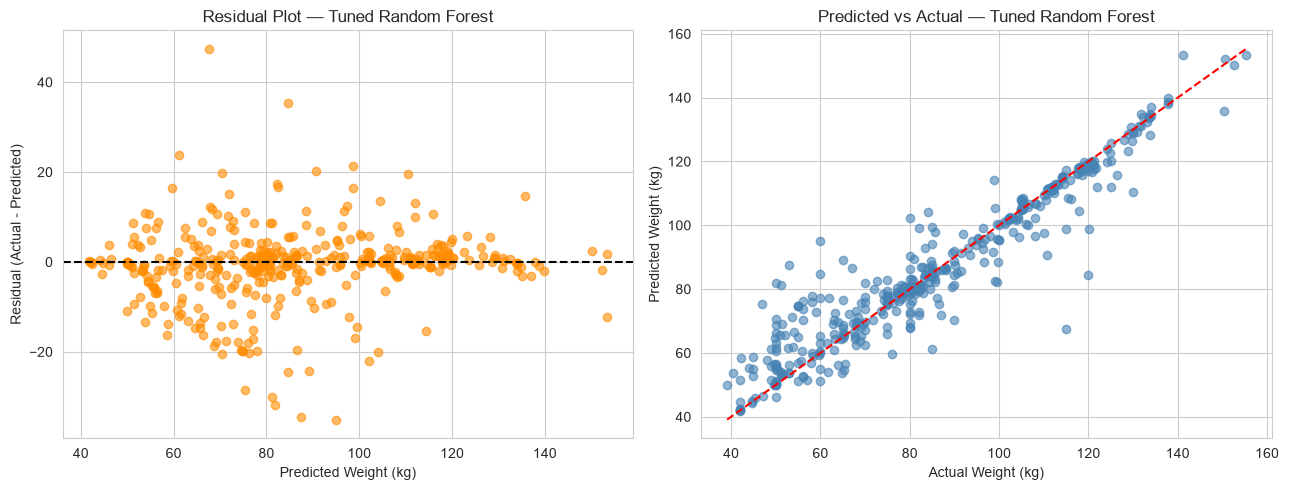

In [20]:
best_model_name = results_df.iloc[0]["Model"]
print("Best model overall:", best_model_name)

# Use the tuned Random Forest as the illustrative "best model" for residual diagnostics
best_preds = rf_tuned_preds
residuals = y_test - best_preds

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(best_preds, residuals, alpha=0.6, color="darkorange")
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_xlabel("Predicted Weight (kg)")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residual Plot — Tuned Random Forest")

axes[1].scatter(y_test, best_preds, alpha=0.6, color="steelblue")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[1].set_xlabel("Actual Weight (kg)")
axes[1].set_ylabel("Predicted Weight (kg)")
axes[1].set_title("Predicted vs Actual — Tuned Random Forest")

plt.tight_layout()
plt.savefig("reg_residual_predvsactual.png", bbox_inches="tight")
plt.show()

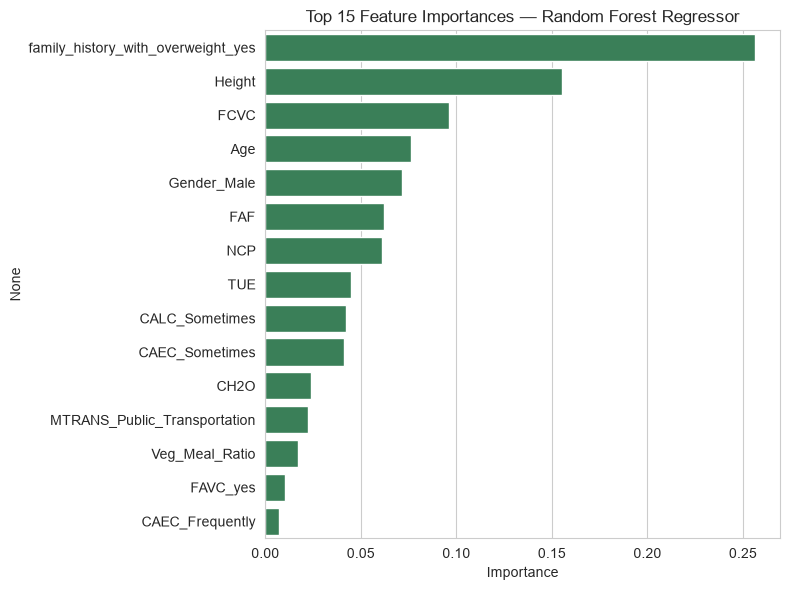

In [21]:
importances = pd.Series(rf_grid.best_estimator_.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, color="seagreen")
plt.title("Top 15 Feature Importances — Random Forest Regressor")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("reg_feature_importance.png", bbox_inches="tight")
plt.show()

## Conclusion — Regression Track
- All 10 required regression algorithms were trained and evaluated on the same 80:20 split.
- **Random Forest** (tuned) gave the strongest R², followed by Gradient Boosting and SVR; plain linear models underfit relative to ensembles, suggesting non-linear relationships between lifestyle features and Weight.
- Hyperparameter tuning via `GridSearchCV` improved both tree-based models over their untuned baselines.
- 5-fold CV confirms the top 2 models generalise consistently (low std across folds).
- `Height`, `Age`, and `Gender` (via one-hot columns) dominate feature importance, aligning with physiological expectations.